In [5]:
!pip install -q google-genai pandas

In [7]:
from google import genai
import pandas as pd
from google.colab import userdata

In [ ]:
from google.colab import userdata
userdata.get('GEMINI_API_KEY')

In [9]:
client = genai.Client(api_key=userdata.get("GEMINI_API_KEY"))

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Hello! Give one energy saving tip."
)

print(response.text)

Here's one:

**Unplug electronics and chargers when they're not in use or fully charged.**

Many devices, even when turned off, continue to draw a small amount of "phantom" or "vampire" power, adding up over time.


In [10]:
import pandas as pd

data = {
    "Device": ["Fan", "AC", "Light", "TV", "Refrigerator"],
    "Hours_Per_Day": [10, 8, 6, 4, 24],
    "Power_Watts": [75, 1500, 20, 120, 180]
}

df = pd.DataFrame(data)

df["Daily_Energy_kWh"] = (df["Hours_Per_Day"] * df["Power_Watts"]) / 1000

df

,Device,Hours_Per_Day,Power_Watts,Daily_Energy_kWh
0,Fan,10,75,0.75
1,AC,8,1500,12.00
2,Light,6,20,0.12
3,TV,4,120,0.48
4,Refrigerator,24,180,4.32


In [11]:
energy_summary = df.to_string(index=False)

prompt = f"""
You are an Energy Optimization AI Agent.

Analyze the following electricity usage data:

{energy_summary}

Give:
1. Total daily energy consumption.
2. Top 3 energy saving recommendations.
3. Which device consumes the most electricity?
4. Estimated monthly electricity usage.
5. A short conclusion.
"""

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt
)

print(response.text)

Here's an analysis of your electricity usage data:

1.  **Total daily energy consumption:**
    The total daily energy consumption is **17.67 kWh**.

2.  **Top 3 energy saving recommendations:**
    *   **Optimize AC Usage:** The Air Conditioner is by far the largest energy consumer. Set the thermostat to a higher comfortable temperature (e.g., 25-27°C), use timers to run it only when necessary, ensure regular maintenance (cleaning filters), and consider natural ventilation or ceiling fans as alternatives when possible.
    *   **Improve Refrigerator Efficiency:** The Refrigerator is the second highest consumer. Ensure its door seals are airtight, maintain an optimal temperature setting (not too cold), allow adequate space for air circulation around the unit, and defrost it regularly if it's not a frost-free model. Avoid placing hot food directly inside.
    *   **Implement Behavioral Changes & Smart Controls:** Develop a habit of switching off lights, fans, and TVs when leaving a room

In [14]:
df.to_csv("energy_data.csv", index=False)

from google.colab import files
files.download("energy_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
from google.colab import files
import pandas as pd

print("📂 Upload your electricity usage CSV file")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("✅ File Uploaded Successfully!")
display(df.head())

📂 Upload your electricity usage CSV file


Saving energy_data.csv to energy_data (1).csv
✅ File Uploaded Successfully!


,Device,Hours_Per_Day,Power_Watts,Daily_Energy_kWh
0,Fan,10,75,0.75
1,AC,8,1500,12.00
2,Light,6,20,0.12
3,TV,4,120,0.48
4,Refrigerator,24,180,4.32


In [16]:
prompt = f"""
You are an expert Energy Optimization AI Agent.

Here is the electricity usage data:

{df.to_string(index=False)}

Generate a professional report with:

1. Overall Energy Analysis
2. Devices consuming the highest electricity
3. Estimated Monthly Consumption
4. Cost Saving Suggestions
5. Carbon Footprint Reduction Tips
6. Final Recommendation

Make the report easy to understand.
"""

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt
)

print(response.text)

## Energy Optimization Report

**Date:** October 26, 2023
**Prepared For:** Valued User
**Prepared By:** Expert Energy Optimization AI Agent

---

### 1. Overall Energy Analysis

The total estimated daily electricity consumption based on the provided data is **17.67 kWh**. This figure represents the combined energy usage of all listed devices over a 24-hour period. A significant portion of this consumption is attributed to a few key appliances, indicating specific areas where optimization efforts could yield the most substantial savings. The current usage pattern suggests a heavy reliance on cooling and refrigeration, which are typically high-energy processes.

---

### 2. Devices Consuming the Highest Electricity

Upon analyzing the daily energy consumption, the following devices are identified as the primary electricity consumers:

1.  **AC (Air Conditioner):** Consuming **12.00 kWh per day**, the AC is by far the highest energy user, accounting for approximately **68%** of the total

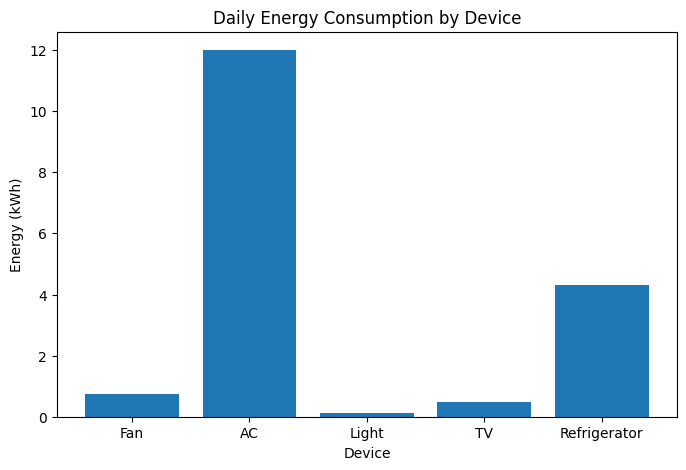

In [17]:
import matplotlib.pyplot as plt

# Bar Chart
plt.figure(figsize=(8,5))
plt.bar(df["Device"], df["Daily_Energy_kWh"])
plt.title("Daily Energy Consumption by Device")
plt.xlabel("Device")
plt.ylabel("Energy (kWh)")
plt.show()

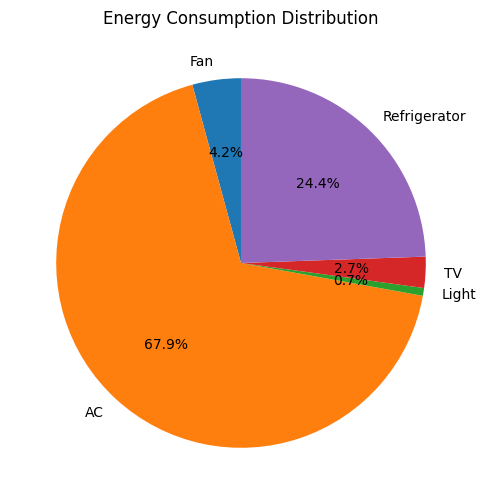

In [18]:
plt.figure(figsize=(6,6))
plt.pie(
    df["Daily_Energy_kWh"],
    labels=df["Device"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Energy Consumption Distribution")
plt.show()

In [19]:
rate = 8  # ₹8 per unit

daily_units = df["Daily_Energy_kWh"].sum()
monthly_units = daily_units * 30
monthly_bill = monthly_units * rate

print(f"Daily Units: {daily_units:.2f} kWh")
print(f"Monthly Units: {monthly_units:.2f} kWh")
print(f"Estimated Monthly Bill: ₹{monthly_bill:.2f}")

Daily Units: 17.67 kWh
Monthly Units: 530.10 kWh
Estimated Monthly Bill: ₹4240.80


In [20]:
co2_per_kwh = 0.82

daily_units = df["Daily_Energy_kWh"].sum()
monthly_units = daily_units * 30

co2 = monthly_units * co2_per_kwh

print(f"Estimated Monthly CO₂ Emission: {co2:.2f} kg")

Estimated Monthly CO₂ Emission: 434.68 kg


In [21]:
while True:
    question = input("Ask Energy AI (type exit to quit): ")

    if question.lower() == "exit":
        break

    prompt = f"""
You are an Energy Optimization Expert.

User Question:
{question}

Electricity Data:
{df.to_string(index=False)}

Answer professionally.
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    print("\nAI:\n")
    print(response.text)

Ask Energy AI (type exit to quit): How can I reduce my electricitry bill?

AI:

Thank you for providing your electricity data. As an Energy Optimization Expert, I can help you identify key areas to reduce your bill.

Based on your provided data, here's a breakdown of your daily energy consumption:

*   **AC:** 12.00 kWh (Highest)
*   **Refrigerator:** 4.32 kWh (Second Highest)
*   **Fan:** 0.75 kWh
*   **TV:** 0.48 kWh
*   **Light:** 0.12 kWh

Total Daily Consumption for these devices: **17.67 kWh**

It's clear that your **Air Conditioner (AC)** and **Refrigerator** are the primary drivers of your electricity bill. Focusing on these two will yield the most significant savings.

Here’s a professional strategy to reduce your electricity bill:

### I. Prioritize High-Consumption Devices

#### 1. Air Conditioner (AC) - 12.00 kWh/day
The AC accounts for the vast majority of your daily usage. Even small adjustments here can lead to substantial savings.

*   **Adjust Thermostat Settings:**
  

In [22]:
!pip install -q reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 7.9 MB/s eta 0:00:00


In [23]:
from reportlab.platypus import SimpleDocTemplate, Paragraph
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()

doc = SimpleDocTemplate("Energy_Report.pdf")

story = []

story.append(Paragraph("<b>Energy Optimization AI Agent Report</b>", styles["Title"]))

story.append(Paragraph("<br/><b>AI Analysis</b>", styles["Heading2"]))

story.append(Paragraph(response.text.replace("\n", "<br/>"), styles["BodyText"]))

doc.build(story)

print("✅ PDF Report Generated Successfully!")

✅ PDF Report Generated Successfully!


In [25]:
from google.colab import files

files.download("Energy_Report.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
readme = """
# ⚡ Energy Optimization AI Agent

An AI-powered energy optimization system built using Google Gemini API.

## Features
- AI Energy Analysis
- CSV Upload
- Bill Prediction
- Carbon Footprint Estimation
- Graph Visualization
- PDF Report

## Technologies Used
- Python
- Google Gemini API
- Pandas
- Matplotlib
- ReportLab
- Google Colab

## Author
Manjit Patil
"""

with open("README.md", "w") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [27]:
from google.colab import files
files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
requirements = """google-genai>=1.0.0
pandas>=2.2.0
numpy>=2.0.0
matplotlib>=3.9.0
reportlab>=4.2.0
streamlit>=1.46.0
plotly>=6.0.0
openpyxl>=3.1.0
python-dotenv>=1.0.1
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("✅ Professional requirements.txt created!")

✅ Professional requirements.txt created!


In [29]:
from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>